# ALL-IDB2 Hybrid Deep Learning Framework

Full notebook according to project report + supervisor comments.

Includes:
- Original ALL-IDB2 reading from filenames `_0` and `_1`
- HSI contrast enhancement
- Saved augmented images + combined dataset
- Train/Validation/Test split
- EfficientNetV2-S + ConvNeXt-Tiny
- Deep feature extraction
- Feature fusion
- Feature optimization/refinement
- Fine-tuning
- Early stopping + ReduceLROnPlateau
- Metrics, confusion matrix, ROC curve
- Saved figures and final model
- Justification text for the report


In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import os
import cv2
import copy
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageEnhance

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [2]:
# =========================================================
# 2. DATASET PATHS
# =========================================================
# BASE_PATH must point directly to the original ALL-IDB2 img folder.

BASE_PATH = r"C:\Users\kadi9\OneDrive\Desktop\GP_project\data\datasets\ALL_IDB2 (2)\ALL_IDB2\img"

# If this does not work, try:
# BASE_PATH = r"C:\Users\kadi9\OneDrive\Desktop\GP_project\data\datasets\ALL_IDB2 (2)\img"

PROJECT_OUTPUT_DIR = r"C:\Users\kadi9\OneDrive\Desktop\GP_project\outputs_allidb2"
AUGMENTED_DATASET_DIR = os.path.join(PROJECT_OUTPUT_DIR, "ALL_IDB2_Original_Plus_Augmented")
FIGURES_DIR = os.path.join(PROJECT_OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(PROJECT_OUTPUT_DIR, "models")

os.makedirs(PROJECT_OUTPUT_DIR, exist_ok=True)
os.makedirs(AUGMENTED_DATASET_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(f"Dataset path was not found: {BASE_PATH}")

print("Dataset path is ready.")
print("Output folders are ready.")


Dataset path is ready.
Output folders are ready.


In [3]:
# =========================================================
# 3. READ ORIGINAL ALL-IDB2 IMAGE PATHS AND LABELS
# =========================================================
# ALL-IDB2 annotation:
# _0 means Healthy
# _1 means ALL / blast cell

original_records = []
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

for file_name in sorted(os.listdir(BASE_PATH)):
    if file_name.lower().endswith(valid_extensions):
        image_path = os.path.join(BASE_PATH, file_name)

        if "_0" in file_name:
            label = 0
            class_name = "Healthy"
        elif "_1" in file_name:
            label = 1
            class_name = "ALL"
        else:
            continue

        original_records.append({
            "path": image_path,
            "label": label,
            "class_name": class_name,
            "file_name": file_name,
            "source": "original"
        })

class_names = ["Healthy", "ALL"]
idx_to_class = {0: "Healthy", 1: "ALL"}
class_to_idx = {"Healthy": 0, "ALL": 1}

print("Original ALL-IDB2 image records loaded successfully.")


Original ALL-IDB2 image records loaded successfully.


In [4]:
# =========================================================
# 4. RGB TO HSI AND HSI TO RGB FUNCTIONS
# =========================================================

def rgb_to_hsi(rgb_image):
    rgb = np.asarray(rgb_image).astype(np.float32) / 255.0

    R = rgb[:, :, 0]
    G = rgb[:, :, 1]
    B = rgb[:, :, 2]

    eps = 1e-8

    numerator = 0.5 * ((R - G) + (R - B))
    denominator = np.sqrt((R - G) ** 2 + (R - B) * (G - B)) + eps

    theta = np.arccos(np.clip(numerator / denominator, -1, 1))

    H = np.where(B <= G, theta, 2 * np.pi - theta)
    H = H / (2 * np.pi)

    min_rgb = np.minimum(np.minimum(R, G), B)
    S = 1 - (3 / (R + G + B + eps)) * min_rgb
    S = np.clip(S, 0, 1)

    I = (R + G + B) / 3.0

    return np.stack((H, S, I), axis=2)


def hsi_to_rgb(hsi_image):
    H = hsi_image[:, :, 0] * 2 * np.pi
    S = hsi_image[:, :, 1]
    I = hsi_image[:, :, 2]

    R = np.zeros_like(H)
    G = np.zeros_like(H)
    B = np.zeros_like(H)

    eps = 1e-8

    idx = (H >= 0) & (H < 2 * np.pi / 3)
    B[idx] = I[idx] * (1 - S[idx])
    R[idx] = I[idx] * (1 + (S[idx] * np.cos(H[idx])) / (np.cos(np.pi / 3 - H[idx]) + eps))
    G[idx] = 3 * I[idx] - (R[idx] + B[idx])

    idx = (H >= 2 * np.pi / 3) & (H < 4 * np.pi / 3)
    H2 = H - 2 * np.pi / 3
    R[idx] = I[idx] * (1 - S[idx])
    G[idx] = I[idx] * (1 + (S[idx] * np.cos(H2[idx])) / (np.cos(np.pi / 3 - H2[idx]) + eps))
    B[idx] = 3 * I[idx] - (R[idx] + G[idx])

    idx = (H >= 4 * np.pi / 3) & (H < 2 * np.pi)
    H3 = H - 4 * np.pi / 3
    G[idx] = I[idx] * (1 - S[idx])
    B[idx] = I[idx] * (1 + (S[idx] * np.cos(H3[idx])) / (np.cos(np.pi / 3 - H3[idx]) + eps))
    R[idx] = 3 * I[idx] - (G[idx] + B[idx])

    rgb = np.stack((R, G, B), axis=2)
    rgb = np.clip(rgb, 0, 1)
    return (rgb * 255).astype(np.uint8)


In [5]:
# =========================================================
# 5. HSI CONTRAST ENHANCEMENT
# =========================================================

def hsi_contrast_enhancement(pil_image):
    rgb_image = np.array(pil_image.convert("RGB"))

    hsi = rgb_to_hsi(rgb_image)

    intensity = hsi[:, :, 2]
    intensity_uint8 = (intensity * 255).astype(np.uint8)

    equalized_intensity = cv2.equalizeHist(intensity_uint8)
    hsi[:, :, 2] = equalized_intensity.astype(np.float32) / 255.0

    enhanced_rgb = hsi_to_rgb(hsi)
    return Image.fromarray(enhanced_rgb)


In [6]:
# =========================================================
# 6. CREATE AUGMENTED DATASET ON DISK
# =========================================================
# This matches the supervisor's suggestion:
# generate augmented images and combine them with the original dataset.

def rotate_image(image, angle):
    return image.rotate(angle)

def horizontal_flip(image):
    return image.transpose(Image.FLIP_LEFT_RIGHT)

def vertical_flip(image):
    return image.transpose(Image.FLIP_TOP_BOTTOM)

def adjust_brightness(image, factor):
    return ImageEnhance.Brightness(image).enhance(factor)

def adjust_contrast(image, factor):
    return ImageEnhance.Contrast(image).enhance(factor)

def augment_pil_image(image):
    augmented_images = []
    augmented_images.append(horizontal_flip(image))
    augmented_images.append(rotate_image(image, 15))
    augmented_images.append(rotate_image(image, -15))
    augmented_images.append(rotate_image(image, 25))
    augmented_images.append(rotate_image(image, -25))
    augmented_images.append(adjust_brightness(image, 1.15))
    augmented_images.append(adjust_brightness(image, 0.90))
    augmented_images.append(adjust_contrast(image, 1.20))
    augmented_images.append(adjust_contrast(image, 0.90))
    return augmented_images

RECREATE_AUGMENTED_DATASET = True

if RECREATE_AUGMENTED_DATASET and os.path.exists(AUGMENTED_DATASET_DIR):
    shutil.rmtree(AUGMENTED_DATASET_DIR)

for class_name in class_names:
    os.makedirs(os.path.join(AUGMENTED_DATASET_DIR, class_name), exist_ok=True)

augmented_records = []

for record in original_records:
    original_image = Image.open(record["path"]).convert("RGB")
    class_folder = os.path.join(AUGMENTED_DATASET_DIR, record["class_name"])
    base_name = os.path.splitext(record["file_name"])[0]

    # Save original image after HSI enhancement
    enhanced_original = hsi_contrast_enhancement(original_image)
    original_save_path = os.path.join(class_folder, f"{base_name}_original.png")
    enhanced_original.save(original_save_path)

    augmented_records.append({
        "path": original_save_path,
        "label": record["label"],
        "class_name": record["class_name"],
        "file_name": os.path.basename(original_save_path),
        "source": "original_hsi"
    })

    # Save augmented images after HSI enhancement
    for aug_idx, aug_image in enumerate(augment_pil_image(original_image)):
        enhanced_aug = hsi_contrast_enhancement(aug_image)
        aug_save_path = os.path.join(class_folder, f"{base_name}_aug_{aug_idx+1}.png")
        enhanced_aug.save(aug_save_path)

        augmented_records.append({
            "path": aug_save_path,
            "label": record["label"],
            "class_name": record["class_name"],
            "file_name": os.path.basename(aug_save_path),
            "source": "augmented_hsi"
        })

print("Original + augmented dataset created successfully.")


Original + augmented dataset created successfully.


In [7]:
# =========================================================
# 7. PREPARE FINAL DATAFRAME
# =========================================================

df = pd.DataFrame(augmented_records)

metadata_path = os.path.join(PROJECT_OUTPUT_DIR, "allidb2_augmented_metadata.csv")
df.to_csv(metadata_path, index=False)

print("Metadata saved successfully.")
print("Classes:", class_names)


Metadata saved successfully.
Classes: ['Healthy', 'ALL']


In [8]:
# =========================================================
# 8. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# =========================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train / validation / test split completed.")


Train / validation / test split completed.


In [9]:
# =========================================================
# 9. IMAGE TRANSFORMS FOR MODEL INPUT
# =========================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [10]:
# =========================================================
# 10. CUSTOM DATASET CLASS
# =========================================================

class ALLIDB2Dataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "path"]
        label = int(self.dataframe.loc[idx, "label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


In [11]:
# =========================================================
# 11. DATALOADERS
# =========================================================

BATCH_SIZE = 8

train_dataset = ALLIDB2Dataset(train_df, transform=train_transform)
val_dataset = ALLIDB2Dataset(val_df, transform=val_test_transform)
test_dataset = ALLIDB2Dataset(test_df, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("DataLoaders created successfully.")


DataLoaders created successfully.


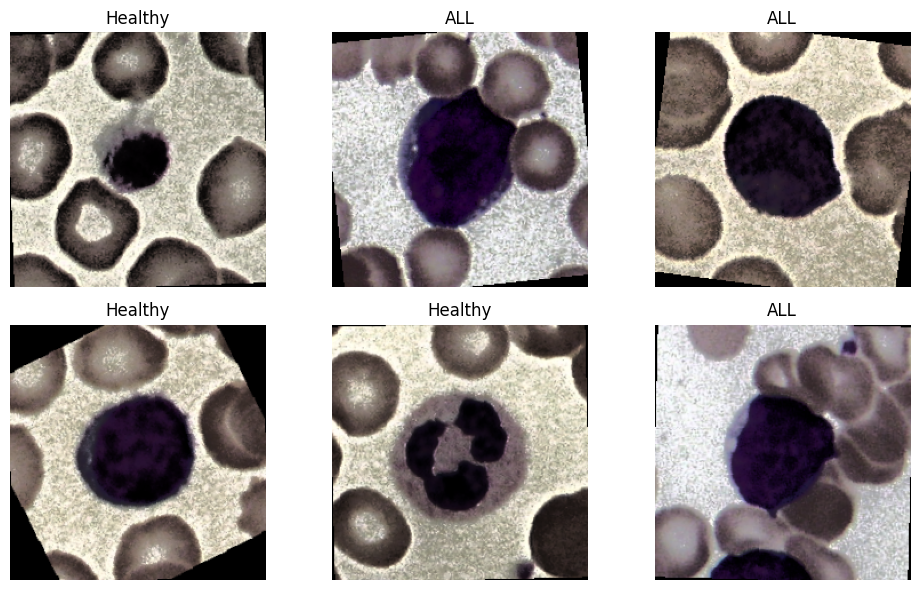

In [12]:
# =========================================================
# 12. VISUALIZE SAMPLE PREPROCESSED IMAGES
# =========================================================

def denormalize_tensor(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = tensor.cpu() * std + mean
    image = torch.clamp(image, 0, 1)
    return image.permute(1, 2, 0).numpy()

images, labels_batch = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(min(6, len(images))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(denormalize_tensor(images[i]))
    plt.title(class_names[int(labels_batch[i])])
    plt.axis("off")

plt.tight_layout()
sample_fig_path = os.path.join(FIGURES_DIR, "sample_preprocessed_images.png")
plt.savefig(sample_fig_path, dpi=300, bbox_inches="tight")
plt.show()


In [13]:
# =========================================================
# 13. HYBRID MODEL: EFFICIENTNETV2-S + CONVNEXT-TINY
# =========================================================

class HybridEfficientNetConvNeXt(nn.Module):

    def __init__(self, num_classes=2):
        super(HybridEfficientNetConvNeXt, self).__init__()

        self.eff = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
        )

        self.conv = models.convnext_tiny(
            weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )

        eff_feature_dim = self.eff.classifier[1].in_features
        conv_feature_dim = self.conv.classifier[2].in_features

        self.eff.classifier = nn.Identity()
        self.conv.classifier[2] = nn.Identity()

        fusion_dim = eff_feature_dim + conv_feature_dim

        self.feature_optimization = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.50),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.40)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        eff_features = self.eff(x)

        conv_features = self.conv(x)
        conv_features = torch.flatten(conv_features, 1)

        fused_features = torch.cat((eff_features, conv_features), dim=1)

        optimized_features = self.feature_optimization(fused_features)

        output = self.classifier(optimized_features)

        return output


model = HybridEfficientNetConvNeXt(num_classes=2).to(DEVICE)
print("Hybrid model created successfully.")


Hybrid model created successfully.


In [14]:
# =========================================================
# 14. FREEZE PRETRAINED BACKBONES
# =========================================================

for param in model.eff.parameters():
    param.requires_grad = False

for param in model.conv.parameters():
    param.requires_grad = False

for param in model.feature_optimization.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

print("Backbones frozen. Feature optimization and classifier layers are trainable.")


Backbones frozen. Feature optimization and classifier layers are trainable.


In [15]:
# =========================================================
# 15. TRAINING PARAMETERS
# =========================================================

INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 5

INITIAL_LR = 1e-3
FINE_TUNE_LR = 1e-5

WEIGHT_DECAY_INITIAL = 1e-4
WEIGHT_DECAY_FINE_TUNE = 1e-5

PATIENCE = 3

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=INITIAL_LR,
    weight_decay=WEIGHT_DECAY_INITIAL
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

training_parameters = {
    "Batch Size": BATCH_SIZE,
    "Initial Epochs": INITIAL_EPOCHS,
    "Fine-tuning Epochs": FINE_TUNE_EPOCHS,
    "Initial Learning Rate": INITIAL_LR,
    "Fine-tuning Learning Rate": FINE_TUNE_LR,
    "Optimizer": "Adam",
    "Loss Function": "CrossEntropyLoss",
    "Scheduler": "ReduceLROnPlateau",
    "Weight Decay Initial": WEIGHT_DECAY_INITIAL,
    "Weight Decay Fine Tune": WEIGHT_DECAY_FINE_TUNE,
    "Early Stopping Patience": PATIENCE,
    "Dropout": "0.50, 0.40, 0.30"
}

training_parameters_df = pd.DataFrame(list(training_parameters.items()), columns=["Parameter", "Value"])
params_path = os.path.join(PROJECT_OUTPUT_DIR, "training_parameters.csv")
training_parameters_df.to_csv(params_path, index=False)

training_parameters_df


,Parameter,Value
0,Batch Size,8
1,Initial Epochs,10
2,Fine-tuning Epochs,5
3,Initial Learning Rate,0.001
4,Fine-tuning Learning Rate,0.00001
5,Optimizer,Adam
6,Loss Function,CrossEntropyLoss
7,Scheduler,ReduceLROnPlateau
8,Weight Decay Initial,0.0001
9,Weight Decay Fine Tune,0.00001


In [16]:
# =========================================================
# 16. TRAINING FUNCTION WITH EARLY STOPPING
# =========================================================

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    epochs=10,
    patience=3,
    save_path="best_model.pth"
):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(epochs):

        model.train()

        train_loss_total = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_loss = train_loss_total / len(train_loader)
        train_acc = train_correct / train_total

        model.eval()

        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_total += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_acc = val_correct / val_total

        if scheduler is not None:
            scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(best_model_weights, save_path)
            patience_counter = 0
            print("Best model saved.")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping activated.")
                break

    model.load_state_dict(best_model_weights)
    return model, history


In [17]:
# =========================================================
# 17. INITIAL TRAINING
# =========================================================

initial_model_path = os.path.join(MODELS_DIR, "best_allidb2_hybrid_initial.pth")

model, history_initial = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=INITIAL_EPOCHS,
    patience=PATIENCE,
    save_path=initial_model_path
)


Epoch 1/10 | Train Loss: 0.2920 | Train Acc: 0.8813 | Val Loss: 0.0888 | Val Acc: 0.9744
Best model saved.
Epoch 2/10 | Train Loss: 0.1776 | Train Acc: 0.9363 | Val Loss: 0.0470 | Val Acc: 0.9769
Best model saved.
Epoch 3/10 | Train Loss: 0.1758 | Train Acc: 0.9363 | Val Loss: 0.0367 | Val Acc: 0.9923
Best model saved.
Epoch 4/10 | Train Loss: 0.1508 | Train Acc: 0.9467 | Val Loss: 0.0189 | Val Acc: 0.9974
Best model saved.
Epoch 5/10 | Train Loss: 0.1603 | Train Acc: 0.9423 | Val Loss: 0.0239 | Val Acc: 0.9974
Epoch 6/10 | Train Loss: 0.1132 | Train Acc: 0.9593 | Val Loss: 0.0062 | Val Acc: 1.0000
Best model saved.
Epoch 7/10 | Train Loss: 0.1237 | Train Acc: 0.9604 | Val Loss: 0.0211 | Val Acc: 0.9974
Epoch 8/10 | Train Loss: 0.0999 | Train Acc: 0.9632 | Val Loss: 0.0275 | Val Acc: 0.9923
Epoch 9/10 | Train Loss: 0.1369 | Train Acc: 0.9533 | Val Loss: 0.0177 | Val Acc: 1.0000
Early stopping activated.


In [18]:
# =========================================================
# 18. FINE-TUNING
# =========================================================

model.load_state_dict(torch.load(initial_model_path, map_location=DEVICE))

for param in model.eff.features[-2:].parameters():
    param.requires_grad = True

for param in model.conv.features[-2:].parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=FINE_TUNE_LR,
    weight_decay=WEIGHT_DECAY_FINE_TUNE
)

scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="min",
    factor=0.5,
    patience=2
)

finetuned_model_path = os.path.join(MODELS_DIR, "best_allidb2_hybrid_finetuned.pth")

model, history_finetune = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft,
    epochs=FINE_TUNE_EPOCHS,
    patience=PATIENCE,
    save_path=finetuned_model_path
)


Epoch 1/5 | Train Loss: 0.0937 | Train Acc: 0.9692 | Val Loss: 0.0054 | Val Acc: 1.0000
Best model saved.
Epoch 2/5 | Train Loss: 0.0870 | Train Acc: 0.9687 | Val Loss: 0.0039 | Val Acc: 1.0000
Best model saved.
Epoch 3/5 | Train Loss: 0.1090 | Train Acc: 0.9621 | Val Loss: 0.0016 | Val Acc: 1.0000
Best model saved.
Epoch 4/5 | Train Loss: 0.1084 | Train Acc: 0.9687 | Val Loss: 0.0027 | Val Acc: 1.0000
Epoch 5/5 | Train Loss: 0.0668 | Train Acc: 0.9775 | Val Loss: 0.0031 | Val Acc: 1.0000


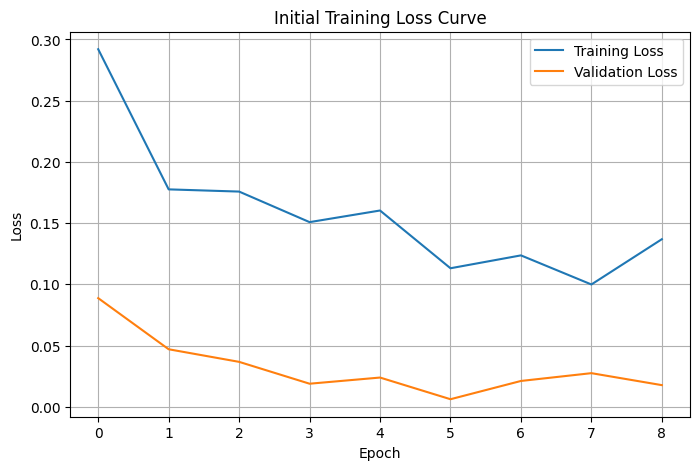

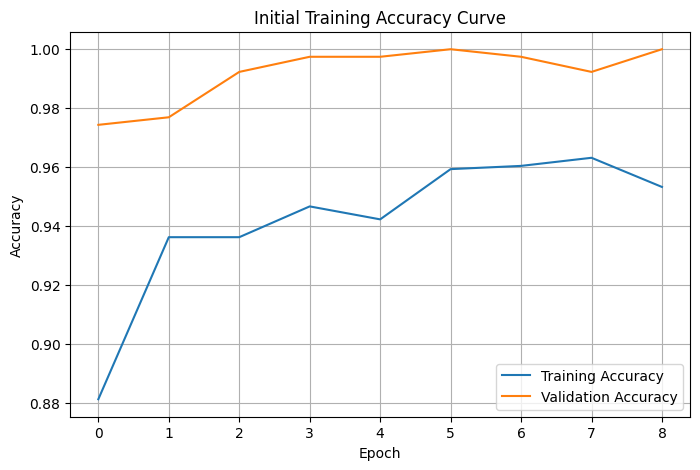

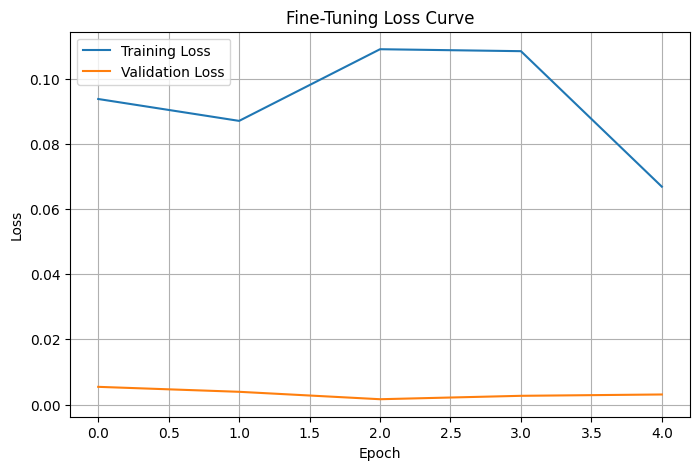

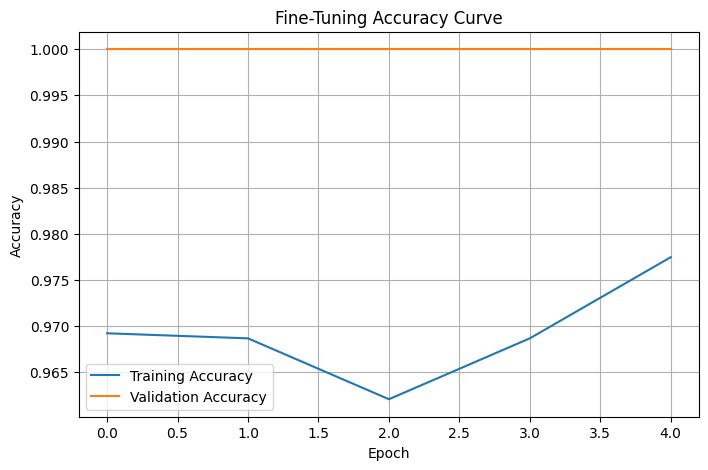

In [19]:
# =========================================================
# 19. PLOT AND SAVE TRAINING CURVES
# =========================================================

def plot_training_curves(history, title_prefix, save_prefix):

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Training Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss Curve")
    plt.legend()
    plt.grid(True)
    save_path = os.path.join(FIGURES_DIR, f"{save_prefix}_loss_curve.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Training Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy Curve")
    plt.legend()
    plt.grid(True)
    save_path = os.path.join(FIGURES_DIR, f"{save_prefix}_accuracy_curve.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_training_curves(history_initial, "Initial Training", "initial_training")
plot_training_curves(history_finetune, "Fine-Tuning", "fine_tuning")


In [20]:
# =========================================================
# 20. TEST EVALUATION
# =========================================================

model.load_state_dict(torch.load(finetuned_model_path, map_location=DEVICE))
model.eval()

all_preds = []
all_labels = []
all_probs = []

test_loss_total = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss_total += loss.item()

        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

test_loss = test_loss_total / len(test_loader)
print("Testing completed successfully.")


Testing completed successfully.


In [21]:
# =========================================================
# 21. PERFORMANCE METRICS
# =========================================================

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)

try:
    roc_auc = roc_auc_score(all_labels, all_probs)
except ValueError:
    roc_auc = 0.0

results = {
    "Test Loss": test_loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc
}

results_df = pd.DataFrame(list(results.items()), columns=["Metric", "Value"])
results_path = os.path.join(PROJECT_OUTPUT_DIR, "final_results.csv")
results_df.to_csv(results_path, index=False)

print("Test Loss:", round(test_loss, 4))
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1-score:", round(f1 * 100, 2), "%")
print("ROC-AUC:", round(roc_auc * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

results_df


Test Loss: 0.004
Accuracy: 99.74 %
Precision: 100.0 %
Recall: 99.49 %
F1-score: 99.74 %
ROC-AUC: 100.0 %

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      1.00      1.00       195
         ALL       1.00      0.99      1.00       195

    accuracy                           1.00       390
   macro avg       1.00      1.00      1.00       390
weighted avg       1.00      1.00      1.00       390



,Metric,Value
0,Test Loss,0.004006
1,Accuracy,0.997436
2,Precision,1.000000
3,Recall,0.994872
4,F1-score,0.997429
5,ROC-AUC,1.000000


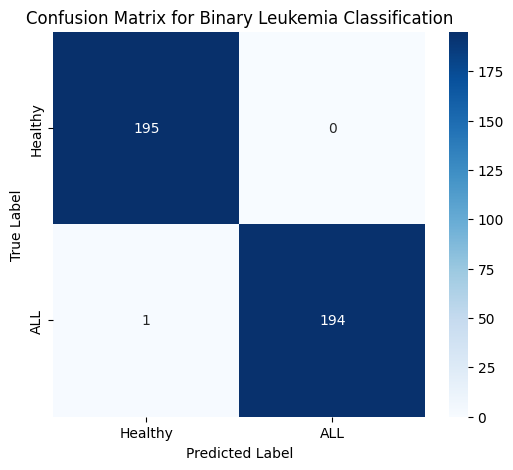

In [22]:
# =========================================================
# 22. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Binary Leukemia Classification")

confusion_matrix_path = os.path.join(FIGURES_DIR, "confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()


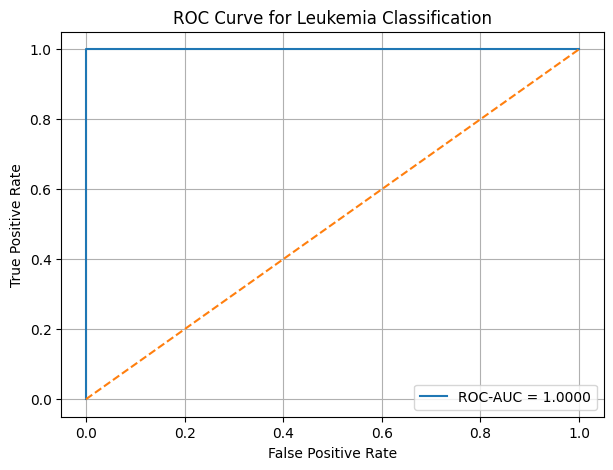

In [27]:
# =========================================================
# 23. ROC CURVE
# =========================================================

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Leukemia Classification")
plt.legend()
plt.grid(True)

roc_curve_path = os.path.join(FIGURES_DIR, "roc_curve.png")
plt.savefig(roc_curve_path, dpi=300, bbox_inches="tight")
plt.show()


In [28]:
# =========================================================
# 24. FEATURE EXTRACTION AND FUSION INSPECTION
# =========================================================

model.eval()

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images.to(DEVICE)

with torch.no_grad():
    eff_features = model.eff(sample_images)

    conv_features = model.conv(sample_images)
    conv_features = torch.flatten(conv_features, 1)

    fused_features = torch.cat((eff_features, conv_features), dim=1)

    optimized_features = model.feature_optimization(fused_features)

print("EfficientNetV2 feature vector shape:", eff_features.shape)
print("ConvNeXt feature vector shape:", conv_features.shape)
print("Fused feature vector shape:", fused_features.shape)
print("Optimized feature vector shape:", optimized_features.shape)


EfficientNetV2 feature vector shape: torch.Size([8, 1280])
ConvNeXt feature vector shape: torch.Size([8, 768])
Fused feature vector shape: torch.Size([8, 2048])
Optimized feature vector shape: torch.Size([8, 256])


In [29]:
# =========================================================
# 25. SINGLE IMAGE PREDICTION FUNCTION
# =========================================================

def predict_single_image(image_path, model, transform):

    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = hsi_contrast_enhancement(image)

    image_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))

    pred_class = class_names[pred_idx]

    return pred_class, probs


# Example:
# image_path = test_df.iloc[0]["path"]
# pred_class, probs = predict_single_image(image_path, model, val_test_transform)
# print("Prediction:", pred_class)
# print("Probabilities:", probs)


In [30]:
# =========================================================
# 26. SAVE FINAL MODEL
# =========================================================

final_model_path = os.path.join(MODELS_DIR, "final_allidb2_hybrid_efficientnetv2_convnext_model.pth")

torch.save(model.state_dict(), final_model_path)

print("Final model saved successfully.")
print(final_model_path)


Final model saved successfully.
C:\Users\kadi9\OneDrive\Desktop\GP_project\outputs_allidb2\models\final_allidb2_hybrid_efficientnetv2_convnext_model.pth


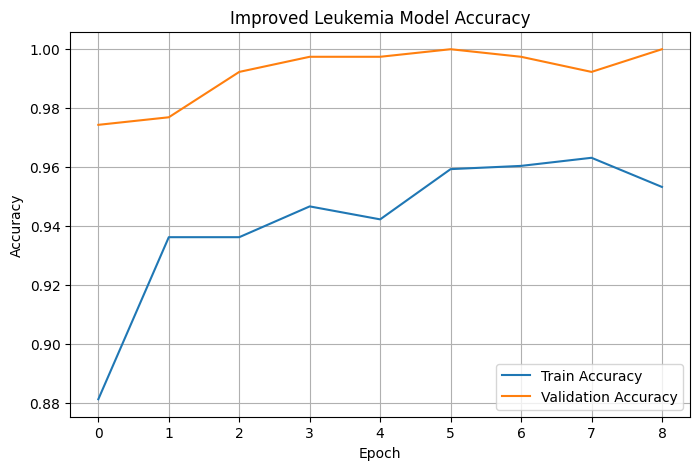

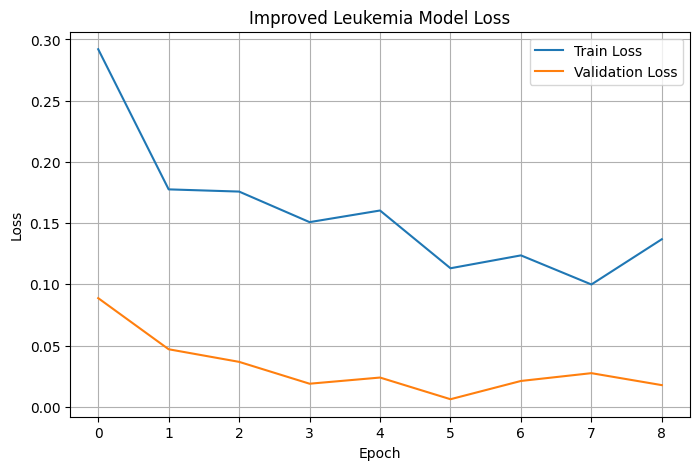

In [31]:
# ==========================================
# TRAINING / VALIDATION CURVES
# ==========================================

import matplotlib.pyplot as plt

# ---- Accuracy Curve ----
plt.figure(figsize=(8,5))

plt.plot(history_initial['train_acc'], label='Train Accuracy')
plt.plot(history_initial['val_acc'], label='Validation Accuracy')

plt.title('Improved Leukemia Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()


# ---- Loss Curve ----
plt.figure(figsize=(8,5))

plt.plot(history_initial['train_loss'], label='Train Loss')
plt.plot(history_initial['val_loss'], label='Validation Loss')

plt.title('Improved Leukemia Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

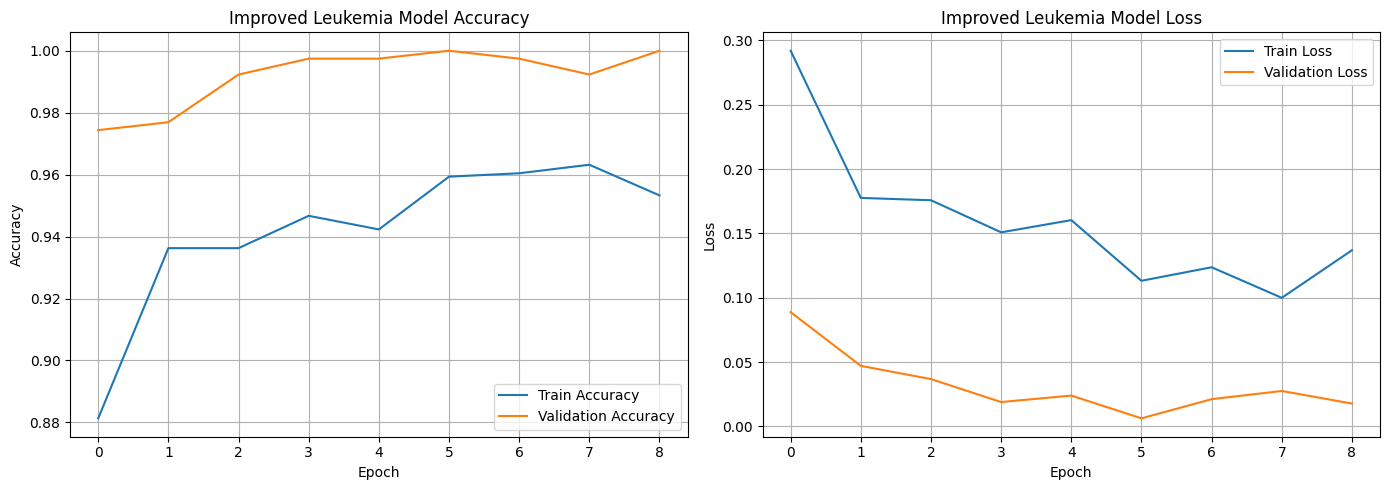

In [32]:
# ==========================================
# COMBINED TRAINING CURVES FIGURE
# ==========================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ==========================================
# ACCURACY CURVE
# ==========================================

axes[0].plot(history_initial['train_acc'], label='Train Accuracy')
axes[0].plot(history_initial['val_acc'], label='Validation Accuracy')

axes[0].set_title('Improved Leukemia Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

axes[0].legend()
axes[0].grid(True)

# ==========================================
# LOSS CURVE
# ==========================================

axes[1].plot(history_initial['train_loss'], label='Train Loss')
axes[1].plot(history_initial['val_loss'], label='Validation Loss')

axes[1].set_title('Improved Leukemia Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

axes[1].legend()
axes[1].grid(True)

# ==========================================
# SAVE + SHOW
# ==========================================

plt.tight_layout()

plt.savefig(
    "improved_training_validation_curves.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()